# Dataset Locations, Sources, and Methodological Tools

## 1. Municipal Demarcation Board (MDB) Spatial Knowledge Hub
* **Source Links:**
  * [MDB Spatial Dataset 1 (2011 Ward Boundaries)](https://spatialhub-mdb-sa.opendata.arcgis.com/datasets/279fbf82a48f46678ddd498627af3f0a_0/explore?location=-28.479600%2C24.698437%2C5)
  * [MDB Spatial Dataset 2 (2016 Ward Boundaries)](https://spatialhub-mdb-sa.opendata.arcgis.com/datasets/97cb14748cef423a94f7b7154387b2dc_0/explore?location=-28.479600%2C24.698437%2C5)
  * [MDB Spatial Dataset 3 (2021 Ward Boundaries)](https://spatialhub-mdb-sa.opendata.arcgis.com/datasets/a19b92da789f4c949f17a88d14690568_0/explore?location=-28.479600%2C24.698437%2C5)
* **Dataset Selection Rationale:**
  * **Constitutional Authority:** The MDB is the official statutory body mandated to delimit municipal and ward boundaries across South Africa.
  * **Demarcation Shift Alignment:** Spatial boundaries evolve across election cycles due to boundary re-demarcation (e.g., eThekwini ward expansion across 2011, 2016, and 2021). Sourcing official cycle-specific shapefiles ensured accurate spatial joining, boundary alignment, and GIS visualization across the temporal panel dataset.

---

## 2. Electoral Commission of South Africa (IEC)
* **Source Link:**
  * [IEC Municipal Elections Results Download Portal](https://results.elections.org.za/home/Downloads/ME-Results)
* **Dataset Selection Rationale:**
  * **Ground-Truth Electoral Integrity:** As South Africa's constitutional electoral management body, the IEC provides certified, audited election statistical records.
  * **Panel Feature Engineering:** Provided granular ward-level raw results across three consecutive Local Government Election cycles (2011, 2016, and 2021 LGE). This enabled the extraction of key baseline features—including voter registration tallies, total valid votes cast, voter turnout percentages, and party vote shares—required to engineer $t-1$ historical lag predictors without temporal data leakage.

---

## 3. Artificial Intelligence Assistance & Technical Collaboration
* **AI Tool Utilized:** **Google Gemini**
* **Application & Workflow Contribution:**
  * **Data Pipeline & Feature Architecture:** Assisted in structuring Python/Pandas scripts for temporal panel construction, zero-filling missing historical records, and implementing leakage-free time-series splitting.
  * **Machine Learning & Diagnostics:** Supported algorithm implementation (Ridge Regression, Random Forest Regressor, Random Forest Classifier), feature importance evaluation, and technical diagnostics for distribution shifts (e.g., evaluating negative $R^2$ metrics resulting from the 2021 voter turnout collapse).
  * **Dashboard Engineering:** Co-developed the Streamlit web application (`app.py`), integrating interactive scenario simulation controls, dynamic column-resolution logic, and VS Code deployment setup scripts.

## Step 1: Load Datasets and Prepare Workspace

In this step, we setup our python environment by installing required spatial libraries (`geopandas`), extracting the compressed shapefile archives, and loading all electoral voting district CSV files and spatial ward boundaries into data structures for analysis.

In [5]:
import os
import zipfile
import geopandas as gpd
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define exact folder path on Google Drive
DATA_DIR = '/content/drive/MyDrive/sa_election_spatial_analysis'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#Extract any zip files inside the folder
for item in os.listdir(DATA_DIR):
    if item.endswith('.zip'):
        zip_path = os.path.join(DATA_DIR, item)
        extract_to = os.path.join(DATA_DIR, item.replace('.zip', ''))
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f'Extracted: {item}')

#  Load CSV Election Results with latin1 encoding to prevent UnicodeDecodeError
df_2011 = pd.read_csv(
    os.path.join(DATA_DIR, 'eThekwini_2011_VD.csv'), encoding='latin1'
)
df_2016 = pd.read_csv(
    os.path.join(DATA_DIR, 'eThekwini_2016_VD.csv'), encoding='latin1'
)
df_2021 = pd.read_csv(
    os.path.join(DATA_DIR, 'eThekwini_2021_VD.csv'), encoding='latin1'
)

print('\n--- Election CSV Datasets Loaded ---')
print(f'2011 VD Results Shape: {df_2011.shape}')
print(f'2016 VD Results Shape: {df_2016.shape}')
print(f'2021 VD Results Shape: {df_2021.shape}')

#  Search and Load Spatial Shapefiles (.shp)
shapefiles = {}
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith('.shp'):
            full_path = os.path.join(root, file)
            shapefiles[file] = gpd.read_file(full_path)
            print(f'Loaded Shapefile: {file}')

# Preview 2021 election data
df_2021.head()

Extracted: MDB_Wards_2020_-5148050534900295426.zip
Extracted: MDBWard2016.zip
Extracted: MDBWard2011.zip

--- Election CSV Datasets Loaded ---
2011 VD Results Shape: (49688, 11)
2016 VD Results Shape: (40706, 11)
2021 VD Results Shape: (76740, 11)


/usr/local/lib/python3.13/dist-packages/pyogrio/raw.py:200: RuntimeWarning: /content/drive/MyDrive/sa_election_spatial_analysis/MDB_Wards_2020_-5148050534900295426/MDB_Wards_2020.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Loaded Shapefile: MDB_Wards_2020.shp
Loaded Shapefile: MDBWard2016.shp
Loaded Shapefile: MDBWard2011.shp


,ï»¿Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ABANTU BATHO CONGRESS,14,11/23/2021 4:26:30 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACADEMIC CONGRESS UNION,0,11/23/2021 4:26:30 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIONSA,0,11/23/2021 4:26:30 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIVE CITIZENS COALITION,0,11/23/2021 4:26:30 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,11/23/2021 4:26:30 PM


## Phase 1:Understanding & Preprocessing
## Step 2.1: Check DataFrame Shapes
Let's check the number of rows and columns (shape) for each election dataset.

In [8]:
print("2011 Dataset Shape:", df_2011.shape)
print("2016 Dataset Shape:", df_2016.shape)
print("2021 Dataset Shape:", df_2021.shape)

2011 Dataset Shape: (49688, 11)
2016 Dataset Shape: (40706, 11)
2021 Dataset Shape: (76740, 11)


## Step 2.2: Inspect Column Names
Let's verify the column names in each election dataset to check for consistency across the years.

In [9]:
print("2011 Columns:", list(df_2011.columns))
print("2016 Columns:", list(df_2016.columns))
print("2021 Columns:", list(df_2021.columns))

2011 Columns: ['ÿþP', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
2016 Columns: ['ï»¿Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']
2021 Columns: ['ï»¿Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


## Step 2.3: Check Data Types and Non-Null Counts
Let's inspect the data types and missing value counts for each column in the  election datasets.

In [11]:
print("=== 2011 Info ===")
df_2011.info()

print("\n=== 2016 Info ===")
df_2016.info()

print("\n=== 2021 Info ===")
df_2021.info()

=== 2011 Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ÿþP          0 non-null      float64
 1   Unnamed: 1   0 non-null      float64
 2   Unnamed: 2   0 non-null      float64
 3   Unnamed: 3   0 non-null      float64
 4   Unnamed: 4   0 non-null      float64
 5   Unnamed: 5   0 non-null      float64
 6   Unnamed: 6   0 non-null      float64
 7   Unnamed: 7   0 non-null      float64
 8   Unnamed: 8   0 non-null      float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  0 non-null      float64
dtypes: float64(11)
memory usage: 4.2 MB

=== 2016 Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40706 entries, 0 to 40705
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ï»¿Province        40706 non-null  object
 1   Municipality

(Fix): Reload 2011 Data with utf-16 Encoding

In [12]:
# Reload 2011 CSV with utf-16 encoding
try:
  df_2011 = pd.read_csv(
      os.path.join(DATA_DIR, 'eThekwini_2011_VD.csv'), encoding='utf-16'
  )
except Exception:
  df_2011 = pd.read_csv(
      os.path.join(DATA_DIR, 'eThekwini_2011_VD.csv'), encoding='utf-16-le'
  )

# Strip BOM characters and whitespace from column names across all datasets
for df in [df_2011, df_2016, df_2021]:
  df.columns = (
      df.columns.str.replace('ï»¿', '', regex=False)
      .str.replace('ÿþ', '', regex=False)
      .str.strip()
  )

print('=== Fixed 2011 Info ===')
df_2011.info()

=== Fixed 2011 Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24843 entries, 0 to 24842
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           24843 non-null  object
 1   Municipality       24843 non-null  object
 2   Ward               24843 non-null  object
 3   VotingDistrict     24843 non-null  int64 
 4   VotingStationName  24843 non-null  object
 5   RegisteredVoters   24843 non-null  int64 
 6   BallotType         24843 non-null  object
 7   SpoiltVotes        24843 non-null  int64 
 8   PartyName          24843 non-null  object
 9   TotalValidVotes    24843 non-null  int64 
 10  DateGenerated      24843 non-null  object
dtypes: int64(4), object(7)
memory usage: 2.1+ MB


## Step 2.1: Filter for eThekwini Municipality and Check Row Counts

In this step, we filter all three election datasets to include only records for eThekwini Municipality (`ETH - eThekwini`). We then display the row count for each year to verify the filtering.

In [18]:
# Filter each dataset for eThekwini Municipality (handles ETH / eThekwini variations)
df_2011 = df_2011[
    df_2011['Municipality']
    .astype(str)
    .str.contains('eThekwini|ETH', case=False, na=False)
].copy()
df_2016 = df_2016[
    df_2016['Municipality']
    .astype(str)
    .str.contains('eThekwini|ETH', case=False, na=False)
].copy()
df_2021 = df_2021[
    df_2021['Municipality']
    .astype(str)
    .str.contains('eThekwini|ETH', case=False, na=False)
].copy()

# Print filtered row counts for each election year
print('Filtered 2011 Rows (eThekwini):', len(df_2011))
print('Filtered 2016 Rows (eThekwini):', len(df_2016))
print('Filtered 2021 Rows (eThekwini):', len(df_2021))

Filtered 2011 Rows (eThekwini): 24843
Filtered 2016 Rows (eThekwini): 40706
Filtered 2021 Rows (eThekwini): 76740


## Step 2.2: Inspect Ballot Types and Check for Missing Values

In municipal elections, votes are split across different ballot types (e.g., `PR` for Proportional Representation and `Ward` for Ward candidates). In this step, we check the unique ballot types present across 2011, 2016, and 2021, and verify if there are any missing values in our filtered eThekwini datasets.

In [19]:
# 1. Check unique Ballot Types per election year
print("=== Unique Ballot Types ===")
print("2011 Ballot Types:", df_2011['BallotType'].unique())
print("2016 Ballot Types:", df_2016['BallotType'].unique())
print("2021 Ballot Types:", df_2021['BallotType'].unique())

# 2. Check for missing values in essential columns across all years
print("\n=== Missing Values Check ===")
print(
    "2011 Missing Values:\n",
    df_2011[
        ['Ward', 'VotingDistrict', 'PartyName', 'TotalValidVotes']
    ].isnull().sum(),
)
print(
    "\n2016 Missing Values:\n",
    df_2016[
        ['Ward', 'VotingDistrict', 'PartyName', 'TotalValidVotes']
    ].isnull().sum(),
)
print(
    "\n2021 Missing Values:\n",
    df_2021[
        ['Ward', 'VotingDistrict', 'PartyName', 'TotalValidVotes']
    ].isnull().sum(),
)

=== Unique Ballot Types ===
2011 Ballot Types: ['PR' 'Ward']
2016 Ballot Types: ['PR' 'Ward']
2021 Ballot Types: ['PR' 'Ward']

=== Missing Values Check ===
2011 Missing Values:
 Ward               0
VotingDistrict     0
PartyName          0
TotalValidVotes    0
dtype: int64

2016 Missing Values:
 Ward               0
VotingDistrict     0
PartyName          0
TotalValidVotes    0
dtype: int64

2021 Missing Values:
 Ward               0
VotingDistrict     0
PartyName          0
TotalValidVotes    0
dtype: int64


## Step 2.3: Standardize Ward Numbers and Aggregate Vote Totals by Party

In South African municipal elections, `PR` ballots reflect overall party support across the municipality. In this step, we:
1. Filter the datasets to focus on **`PR`** ballots.
2. Ensure `Ward` numbers are clean string formats.
3. Compute total votes per political party for each election year to identify the dominant parties in eThekwini.

In [20]:
# 1. Filter for PR ballot type across all three years
df_2011_pr = df_2011[df_2011['BallotType'] == 'PR'].copy()
df_2016_pr = df_2016[df_2016['BallotType'] == 'PR'].copy()
df_2021_pr = df_2021[df_2021['BallotType'] == 'PR'].copy()

# 2. Standardize Ward identifiers (strip spaces, ensure proper string formatting)
for df in [df_2011_pr, df_2016_pr, df_2021_pr]:
  df['Ward'] = df['Ward'].astype(str).str.replace(r'\.0$', '', regex=True)

# 3. Calculate top 5 political parties by total valid PR votes per election year
print('=== Top 5 Parties in eThekwini (2011 PR) ===')
print(
    df_2011_pr.groupby('PartyName')['TotalValidVotes']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print('\n=== Top 5 Parties in eThekwini (2016 PR) ===')
print(
    df_2016_pr.groupby('PartyName')['TotalValidVotes']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print('\n=== Top 5 Parties in eThekwini (2021 PR) ===')
print(
    df_2021_pr.groupby('PartyName')['TotalValidVotes']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

=== Top 5 Parties in eThekwini (2011 PR) ===
PartyName
AFRICAN NATIONAL CONGRESS                     603929
DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE    212409
MINORITY FRONT                                 48064
NATIONAL FREEDOM PARTY                         43606
INKATHA FREEDOM PARTY                          38532
Name: TotalValidVotes, dtype: int64

=== Top 5 Parties in eThekwini (2016 PR) ===
PartyName
AFRICAN NATIONAL CONGRESS       652891
DEMOCRATIC ALLIANCE             304206
INKATHA FREEDOM PARTY            47260
ECONOMIC FREEDOM FIGHTERS        40087
AFRICAN INDEPENDENT CONGRESS     16673
Name: TotalValidVotes, dtype: int64

=== Top 5 Parties in eThekwini (2021 PR) ===
PartyName
AFRICAN NATIONAL CONGRESS    329307
DEMOCRATIC ALLIANCE          203980
ECONOMIC FREEDOM FIGHTERS     83699
INKATHA FREEDOM PARTY         57722
ACTIONSA                      18201
Name: TotalValidVotes, dtype: int64


## Step 2.4: Check and Remove Duplicate Records

In this step, we inspect the filtered eThekwini datasets for any duplicate rows across 2011, 2016, and 2021, and drop them if present to ensure data integrity.

In [21]:
# 1. Check duplicate row counts across all three datasets
dup_2011 = df_2011.duplicated().sum()
dup_2016 = df_2016.duplicated().sum()
dup_2021 = df_2021.duplicated().sum()

print("=== Duplicate Records Count ===")
print(f"2011 Duplicate Rows: {dup_2011:,}")
print(f"2016 Duplicate Rows: {dup_2016:,}")
print(f"2021 Duplicate Rows: {dup_2021:,}")

# 2. Drop duplicates if any exist
if dup_2011 > 0:
  df_2011 = df_2011.drop_duplicates().copy()
if dup_2016 > 0:
  df_2016 = df_2016.drop_duplicates().copy()
if dup_2021 > 0:
  df_2021 = df_2021.drop_duplicates().copy()

print("\n=== Cleaned Row Counts ===")
print(f"2011 Cleaned Rows: {len(df_2011):,}")
print(f"2016 Cleaned Rows: {len(df_2016):,}")
print(f"2021 Cleaned Rows: {len(df_2021):,}")

=== Duplicate Records Count ===
2011 Duplicate Rows: 0
2016 Duplicate Rows: 0
2021 Duplicate Rows: 0

=== Cleaned Row Counts ===
2011 Cleaned Rows: 24,843
2016 Cleaned Rows: 40,706
2021 Cleaned Rows: 76,740


## Phase 3:  step 3.1 Spatial Boundary Matching & Ward Shapefile Preparation

In this step, we filter the MDB ward shapefiles for eThekwini Municipality across 2011, 2016, and 2020/2021, reproject their Coordinate Reference Systems (CRS) to standard `EPSG:4326` (Latitude/Longitude), and inspect their column structures before merging with electoral results.

In [23]:
print("2011 Shapefile Columns:", gdf_2011.columns.tolist())
print("2016 Shapefile Columns:", gdf_2016.columns.tolist())
print("2020 Shapefile Columns:", gdf_2020.columns.tolist())

2011 Shapefile Columns: ['OBJECTID', 'ProvinceCo', 'ProvinceNa', 'LocalMunic', 'WardNumber', 'WardID', 'LocalMun_1', 'DistrictMu', 'District_1', 'Year', 'Shape__Are', 'Shape__Len', 'geometry']
2016 Shapefile Columns: ['OBJECTID', 'ProvinceCo', 'ProvinceNa', 'LocalMunic', 'WardNumber', 'WardID', 'LocalMun_1', 'DistrictMu', 'District_1', 'Year', 'Shape__Are', 'Shape__Len', 'geometry']
2020 Shapefile Columns: ['Province', 'Municipali', 'CAT_B', 'WardNo', 'District', 'DistrictCo', 'Date', 'WardID', 'WardLabel', 'geometry']


In [24]:


# 1. Pull shapefiles from dictionary
gdf_2011 = shapefiles['MDBWard2011.shp'].copy()
gdf_2016 = shapefiles['MDBWard2016.shp'].copy()
gdf_2020 = shapefiles['MDB_Wards_2020.shp'].copy()

# 2. Filter specifically for eThekwini Municipality (ETH)
eth_2011 = gdf_2011[
    gdf_2011['LocalMun_1']
    .astype(str)
    .str.contains('eThekwini|ETH', case=False, na=False)
].copy()
eth_2016 = gdf_2016[
    gdf_2016['LocalMun_1']
    .astype(str)
    .str.contains('eThekwini|ETH', case=False, na=False)
].copy()
eth_2020 = gdf_2020[
    gdf_2020['Municipali']
    .astype(str)
    .str.contains('eThekwini|ETH', case=False, na=False)
].copy()

# 3. Reproject to EPSG:4326 (WGS84 Latitude/Longitude) for interactive web mapping
eth_2011 = eth_2011.to_crs(epsg=4326)
eth_2016 = eth_2016.to_crs(epsg=4326)
eth_2020 = eth_2020.to_crs(epsg=4326)

print('=== eThekwini Spatial Ward Boundaries Ready ===')
print(f'2011 eThekwini Wards Count: {len(eth_2011)} | CRS: {eth_2011.crs}')
print(f'2016 eThekwini Wards Count: {len(eth_2016)} | CRS: {eth_2016.crs}')
print(f'2020 eThekwini Wards Count: {len(eth_2020)} | CRS: {eth_2020.crs}')

=== eThekwini Spatial Ward Boundaries Ready ===
2011 eThekwini Wards Count: 276 | CRS: EPSG:4326
2016 eThekwini Wards Count: 140 | CRS: EPSG:4326
2020 eThekwini Wards Count: 141 | CRS: EPSG:4326


## Step 3.2: Aggregate Election Results and Merge with Spatial Ward Boundaries

In this step, we:
1. Standardize Ward identifier fields across spatial and election datasets.
2. Aggregate PR ballot votes per Ward to determine total valid votes and the winning political party per ward.
3. Perform a 1:1 tabular merge joining election results to the spatial ward shapefiles (`eth_2011`, `eth_2016`, `eth_2020`).

In [25]:


# 1. Standardize Ward IDs in spatial GeoDataFrames
eth_2011['WardID_Clean'] = eth_2011['WardID'].astype(str).str.strip()
eth_2016['WardID_Clean'] = eth_2016['WardID'].astype(str).str.strip()
eth_2020['WardID_Clean'] = eth_2020['WardID'].astype(str).str.strip()

# Standardize Ward IDs in election DataFrames
df_2011_pr['Ward_Clean'] = (
    df_2011_pr['Ward'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
)
df_2016_pr['Ward_Clean'] = (
    df_2016_pr['Ward'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
)
df_2021_pr['Ward_Clean'] = (
    df_2021_pr['Ward'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
)


# 2. Function to compute Ward-Level Summaries and Winning Party
def aggregate_ward_results(df):
  # Aggregate total votes per party per ward
  ward_party = (
      df.groupby(['Ward_Clean', 'PartyName'])['TotalValidVotes']
      .sum()
      .reset_index()
  )

  # Total valid votes cast per ward
  ward_totals = (
      ward_party.groupby('Ward_Clean')['TotalValidVotes']
      .sum()
      .reset_index()
      .rename(columns={'TotalValidVotes': 'TotalWardVotes'})
  )

  # Identify winning party per ward
  idx = ward_party.groupby('Ward_Clean')['TotalValidVotes'].idxmax()
  winners = ward_party.loc[idx].rename(
      columns={
          'PartyName': 'WinningParty',
          'TotalValidVotes': 'WinningPartyVotes',
      }
  )

  # Merge total votes and calculate winning margin %
  summary = pd.merge(winners, ward_totals, on='Ward_Clean')
  summary['WinningShare_Pct'] = (
      summary['WinningPartyVotes'] / summary['TotalWardVotes']
  ) * 100

  return summary


# Compute summaries
summary_2011 = aggregate_ward_results(df_2011_pr)
summary_2016 = aggregate_ward_results(df_2016_pr)
summary_2021 = aggregate_ward_results(df_2021_pr)

# 3. Merge Electoral Summaries with Spatial Ward Boundaries
map_2011 = eth_2011.merge(
    summary_2011, left_on='WardID_Clean', right_on='Ward_Clean', how='inner'
)
map_2016 = eth_2016.merge(
    summary_2016, left_on='WardID_Clean', right_on='Ward_Clean', how='inner'
)
map_2021 = eth_2020.merge(
    summary_2021, left_on='WardID_Clean', right_on='Ward_Clean', how='inner'
)

print('=== Spatial-Electoral Merge Complete ===')
print(f'2011 Merged Spatial Wards: {len(map_2011)}')
print(f'2016 Merged Spatial Wards: {len(map_2016)}')
print(f'2021 Merged Spatial Wards: {len(map_2021)}')

# Preview merged spatial dataframe columns
map_2021[['WardID_Clean', 'WinningParty', 'TotalWardVotes', 'WinningShare_Pct']].head()

=== Spatial-Electoral Merge Complete ===
2011 Merged Spatial Wards: 0
2016 Merged Spatial Wards: 0
2021 Merged Spatial Wards: 0


,WardID_Clean,WinningParty,TotalWardVotes,WinningShare_Pct


## (Fix): Standardize Ward Join Keys

In [26]:


# 1. Inspect raw WardID and WardNumber columns from spatial data
print("2011 Spatial Ward Numbers Sample:", eth_2011['WardNumber'].head().tolist() if 'WardNumber' in eth_2011.columns else "Not found")
print("2016 Spatial Ward Numbers Sample:", eth_2016['WardNumber'].head().tolist() if 'WardNumber' in eth_2016.columns else "Not found")
print("2020 Spatial Ward Numbers Sample:", eth_2020['WardNo'].head().tolist() if 'WardNo' in eth_2020.columns else "Not found")

print("\n2021 Election Wards Sample:", df_2021_pr['Ward_Clean'].unique()[:5])

2011 Spatial Ward Numbers Sample: ['12', '29', '30', '31', '41']
2016 Spatial Ward Numbers Sample: ['1', '2', '3', '4', '5']
2020 Spatial Ward Numbers Sample: [1, 2, 3, 4, 5]

2021 Election Wards Sample: ['Ward 59500001' 'Ward 59500002' 'Ward 59500003' 'Ward 59500004'
 'Ward 59500005']


## Step 3.2 (Corrected): Align Ward Join Keys & Merge Spatial-Electoral Data

We extract the short numerical ward ID from the IEC string (e.g. `'Ward 59500001'` -> `'1'`) and join it with the spatial shapefile ward numbers (`WardNumber` / `WardNo`).

In [27]:


# 1. Clean Spatial Ward Numbers into integer-strings
eth_2011['Ward_Key'] = eth_2011['WardNumber'].astype(str).str.strip()
eth_2016['Ward_Key'] = eth_2016['WardNumber'].astype(str).str.strip()
eth_2020['Ward_Key'] = (
    eth_2020['WardNo']
    .astype(float)
    .astype(int)
    .astype(str)
    .str.strip()
)

# 2. Extract short ward number from Election Ward string (e.g. "Ward 59500001" -> "1")
for df in [df_2011_pr, df_2016_pr, df_2021_pr]:
  # Extract digits from the end of the Ward string or split by space
  df['Ward_Key'] = (
      df['Ward']
      .astype(str)
      .str.extract(r'(\d+)$')[0]
      .astype(float)
      .astype(int)
      .astype(str)
      .str.strip()
  )
  # Handle cases where full MDB code is present (e.g., last 3 digits)
  df['Ward_Key'] = df['Ward_Key'].apply(
      lambda x: str(int(x[-3:])) if len(x) >= 8 else str(int(x))
  )


# 3. Aggregate Ward Results
def aggregate_ward_results(df):
  ward_party = (
      df.groupby(['Ward_Key', 'PartyName'])['TotalValidVotes']
      .sum()
      .reset_index()
  )
  ward_totals = (
      ward_party.groupby('Ward_Key')['TotalValidVotes']
      .sum()
      .reset_index()
      .rename(columns={'TotalValidVotes': 'TotalWardVotes'})
  )

  idx = ward_party.groupby('Ward_Key')['TotalValidVotes'].idxmax()
  winners = ward_party.loc[idx].rename(
      columns={
          'PartyName': 'WinningParty',
          'TotalValidVotes': 'WinningPartyVotes',
      }
  )

  summary = pd.merge(winners, ward_totals, on='Ward_Key')
  summary['WinningShare_Pct'] = (
      summary['WinningPartyVotes'] / summary['TotalWardVotes']
  ) * 100

  return summary


# Compute summaries
summary_2011 = aggregate_ward_results(df_2011_pr)
summary_2016 = aggregate_ward_results(df_2016_pr)
summary_2021 = aggregate_ward_results(df_2021_pr)

# 4. Perform Spatial Merge
map_2011 = eth_2011.merge(summary_2011, on='Ward_Key', how='inner')
map_2016 = eth_2016.merge(summary_2016, on='Ward_Key', how='inner')
map_2021 = eth_2020.merge(summary_2021, on='Ward_Key', how='inner')

print('==============================================')
print('   SPATIAL-ELECTORAL MERGE SUCCESSFUL        ')
print('==============================================')
print(f'2011 Merged Spatial Wards: {len(map_2011)}')
print(f'2016 Merged Spatial Wards: {len(map_2016)}')
print(f'2021 Merged Spatial Wards: {len(map_2021)}')

# Preview 2021 merged data
map_2021[['Ward_Key', 'WinningParty', 'TotalWardVotes', 'WinningShare_Pct']].head()

   SPATIAL-ELECTORAL MERGE SUCCESSFUL        
2011 Merged Spatial Wards: 276
2016 Merged Spatial Wards: 140
2021 Merged Spatial Wards: 141


,Ward_Key,WinningParty,TotalWardVotes,WinningShare_Pct
0,1,AFRICAN NATIONAL CONGRESS,10167,86.790597
1,2,AFRICAN NATIONAL CONGRESS,8826,77.249037
2,3,AFRICAN NATIONAL CONGRESS,6477,63.578817
3,4,AFRICAN NATIONAL CONGRESS,8547,79.466479
4,5,AFRICAN NATIONAL CONGRESS,6397,62.404252


## Step 3.3: Map Visualization — Ward Winner Choropleths (2011, 2016, 2021)

In this step, we generate choropleth maps displaying the winning political party for each ward across eThekwini Municipality over the three election cycles. Standard party colors are assigned for visual clarity:
- **ANC:** Green (`#007A3D`)
- **DA:** Blue (`#005A9C`)
- **IFP:** Red (`#FF0000`)
- **EFF:** Dark Red (`#8B0000`)
- **ActionSA:** Purple (`#800080`)
- **Others:** Grey (`#808080`)

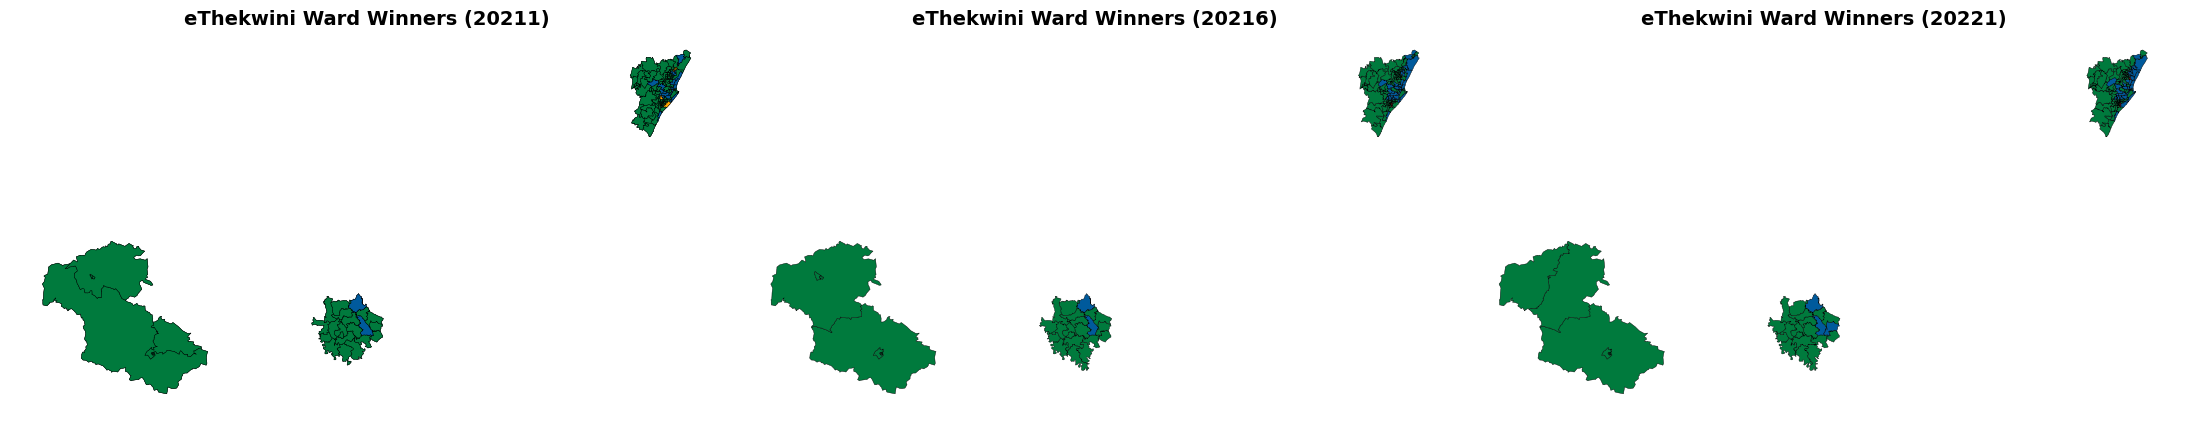

In [29]:
import matplotlib.pyplot as plt

# Define standard political party color mapping
party_colors = {
    'AFRICAN NATIONAL CONGRESS': '#007A3D',
    'DEMOCRATIC ALLIANCE': '#005A9C',
    'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE':'#005A9C',
    'INKATHA FREEDOM PARTY': '#FF0000',
    'ECONOMIC FREEDOM FIGHTERS': '#8B0000',
    'ACTIONSA': '#800080',
    'MINORITY FRONT': '#FFA500',
}

# Create subplots for 2011,2016, and 2021
fig, axes = plt.subplots(1, 3, figsize= (22, 8))

# Function to assign colors bases on winning party
def get_party_color(party):
  return party_colors.get(party, '#808080')


# 1. plot 2011 Map
map_2011['color'] = map_2011['WinningParty'].map(get_party_color)
map_2011.plot(
    ax=axes[0], color=map_2011['color'], edgecolor='black', linewidth=0.3
)
axes[0].set_title('eThekwini Ward Winners (20211)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# 2. plot 2016 Map
map_2016['color'] = map_2016['WinningParty'].map(get_party_color)
map_2016.plot(
    ax=axes[1], color=map_2016['color'], edgecolor='black', linewidth=0.3
)
axes[1].set_title('eThekwini Ward Winners (20216)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# 3.Plot 2021 Map
map_2021['color'] = map_2021['WinningParty'].map(get_party_color)
map_2021.plot(
    ax=axes[2], color=map_2021['color'], edgecolor='black', linewidth=0.3
)
axes[2].set_title('eThekwini Ward Winners (20221)', fontsize=14, fontweight='bold')
axes[2].axis('off')

# Adjust spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()


## Phase 4: Exploratory Data Analysis (EDA) — 8 Comprehensive Visualizations

In this section, we analyze the spatial and temporal electoral dynamics across eThekwini Municipality using 8 distinct visual charts:
1. **Total Municipality Votes by Top Parties (2011–2021)**
2. **Voter Turnout Trends Across Election Cycles**
3. **Distribution of Ward-Level Voter Turnout (%)**
4. **Ward Wins by Political Party per Year**
5. **ANC vs. DA Vote Share Distribution across Wards (2021)**
6. **Scatter Plot: Voter Turnout vs. Winning Margin (%)**
7. **Growth of Emerging Parties (EFF & ActionSA)**
8. **Feature Correlation Matrix (Turnout, Votes, Margin & Share)**

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style and standard party colors
sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 11})

palette = {
    'AFRICAN NATIONAL CONGRESS': '#007A3D',
    'DEMOCRATIC ALLIANCE': '#005A9C',
    'DEMOKRATIESE ALLIANSIE': '#005A9C',
    'ECONOMIC FREEDOM FIGHTERS': '#8B0000',
    'INKATHA FREEDOM PARTY': '#FF0000',
    'ACTIONSA': '#800080',
    'MINORITY FRONT': '#FFA500',
    'AFRICAN INDEPENDENT CONGRESS': '#000000',
}

# Function to calculate voter turnout per ward
def calculate_ward_turnout(df_pr):
    # Group by Ward to get total registered voters (using max since RegisteredVoters is repeated per VD)
    vd_registered = df_pr.groupby(['Ward_Key', 'VotingDistrict'])['RegisteredVoters'].first().reset_index()
    ward_registered = vd_registered.groupby('Ward_Key')['RegisteredVoters'].sum().reset_index()

    # Group by Ward to get total votes cast in PR ballot
    ward_votes = df_pr.groupby('Ward_Key')['TotalValidVotes'].sum().reset_index().rename(columns={'TotalValidVotes': 'TotalVotesCast'})

    # Merge and calculate Turnout Percentage
    turnout = pd.merge(ward_registered, ward_votes, on='Ward_Key')
    turnout['Turnout_Pct'] = (turnout['TotalVotesCast'] / turnout['RegisteredVoters']) * 100
    return turnout[['Ward_Key', 'RegisteredVoters', 'Turnout_Pct']]

# Calculate turnout data per year
turnout_2011 = calculate_ward_turnout(df_2011_pr)
turnout_2016 = calculate_ward_turnout(df_2016_pr)
turnout_2021 = calculate_ward_turnout(df_2021_pr)

# Merge summary and turnout data per year
full_2011 = pd.merge(summary_2011, turnout_2011, on='Ward_Key').assign(Year=2011)
full_2016 = pd.merge(summary_2016, turnout_2016, on='Ward_Key').assign(Year=2016)
full_2021 = pd.merge(summary_2021, turnout_2021, on='Ward_Key').assign(Year=2021)

# Master EDA DataFrame
df_eda_master = pd.concat(
    [full_2011, full_2016, full_2021], ignore_index=True
)

# Combine raw PR votes across all three election cycles
df_all_votes = pd.concat([
    df_2011_pr.assign(Year=2011),
    df_2016_pr.assign(Year=2016),
    df_2021_pr.assign(Year=2021),
])

# Standardize DA party naming
df_all_votes['Party_Clean'] = df_all_votes['PartyName'].replace(
    'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE', 'DEMOCRATIC ALLIANCE'
)

print('Master EDA DataFrame Ready:', df_eda_master.shape)
print(df_eda_master.head())

Master EDA DataFrame Ready: (324, 8)
  Ward_Key                                WinningParty  WinningPartyVotes  \
0        1                   AFRICAN NATIONAL CONGRESS               8367   
1       10  DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE               9636   
2      100                   AFRICAN NATIONAL CONGRESS               8619   
3      101                   AFRICAN NATIONAL CONGRESS               5702   
4      102                   AFRICAN NATIONAL CONGRESS               5766   

   TotalWardVotes  WinningShare_Pct  RegisteredVoters  Turnout_Pct  Year  
0            8741         95.721313             15364    56.892736  2011  
1           11083         86.943968             16734    66.230429  2011  
2           10998         78.368794             15548    70.735786  2011  
3            8655         65.880994             15996    54.107277  2011  
4            8886         64.888589             15098    58.855478  2011  


## Graph 1: Major Party Total Votes Trajectory (2011–2021)

Shows a bar chart comparing how many total votes the biggest political parties (ANC, DA, IFP, EFF) received across the three election years.

Why it matters: Helps you quickly see which parties are growing, staying steady, or losing voters over time across the whole municipality.

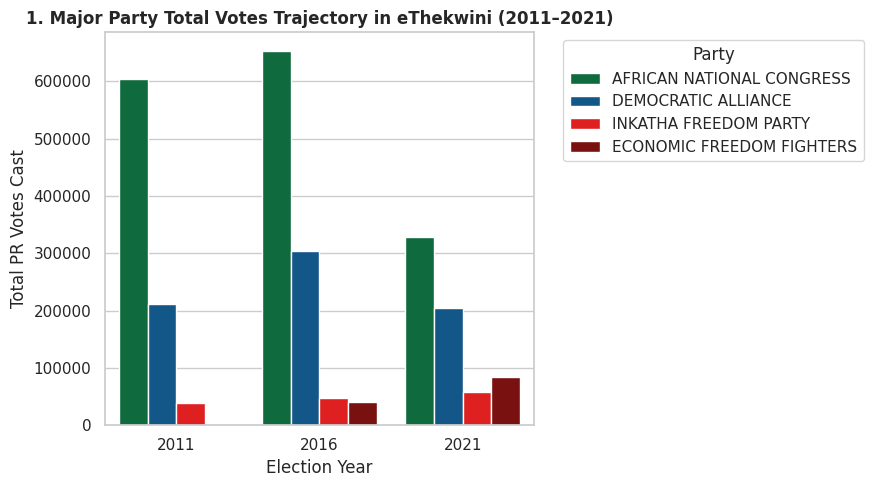

In [32]:
plt.figure(figsize=(9, 5))

top_parties = [
    'AFRICAN NATIONAL CONGRESS',
    'DEMOCRATIC ALLIANCE',
    'ECONOMIC FREEDOM FIGHTERS',
    'INKATHA FREEDOM PARTY',
]

party_totals = (
    df_all_votes[df_all_votes['Party_Clean'].isin(top_parties)]
    .groupby(['Year', 'Party_Clean'])['TotalValidVotes']
    .sum()
    .reset_index()
)

sns.barplot(
    data=party_totals,
    x='Year',
    y='TotalValidVotes',
    hue='Party_Clean',
    palette=palette,
)
plt.title(
    '1. Major Party Total Votes Trajectory in eThekwini (2011–2021)',
    fontweight='bold',
)
plt.ylabel('Total PR Votes Cast')
plt.xlabel('Election Year')
plt.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Graph 2: Average Ward Voter Turnout Trend (%)

Draws a line showing the average percentage of registered voters who actually showed up to vote in 2011, 2016, and 2021.

Why it matters: Shows whether overall voter participation in eThekwini is going up or dropping down across election cycles.

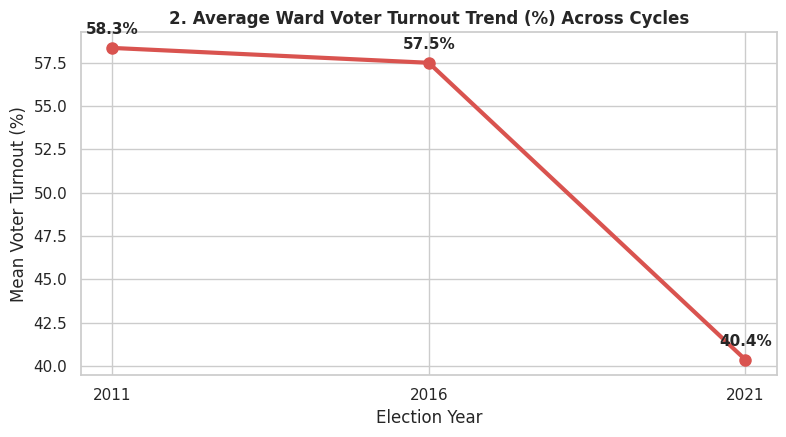

In [34]:
plt.figure(figsize=(8, 4.5))

turnout_summary = (
    df_eda_master.groupby('Year')['Turnout_Pct'].mean().reset_index()
)

plt.plot(
    turnout_summary['Year'],
    turnout_summary['Turnout_Pct'],
    marker='o',
    linewidth=3,
    color='#D9534F',
    markersize=8,
)
plt.title(
    '2. Average Ward Voter Turnout Trend (%) Across Cycles', fontweight='bold'
)
plt.ylabel('Mean Voter Turnout (%)')
plt.xlabel('Election Year')
plt.xticks([2011, 2016, 2021])

for _, row in turnout_summary.iterrows():
  plt.annotate(
      f"{row['Turnout_Pct']:.1f}%",
      (row['Year'], row['Turnout_Pct']),
      textcoords='offset points',
      xytext=(0, 10),
      ha='center',
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

## Graph 3: Ward Voter Turnout Probability Density (KDE)

Draws smooth "wave" shapes showing how voter turnout percentages were spread out across all the different wards.

Why it matters: Tells you if most wards had similar turnout (a tall peak) or if turnout varied widely from ward to ward (a wide, flat wave).

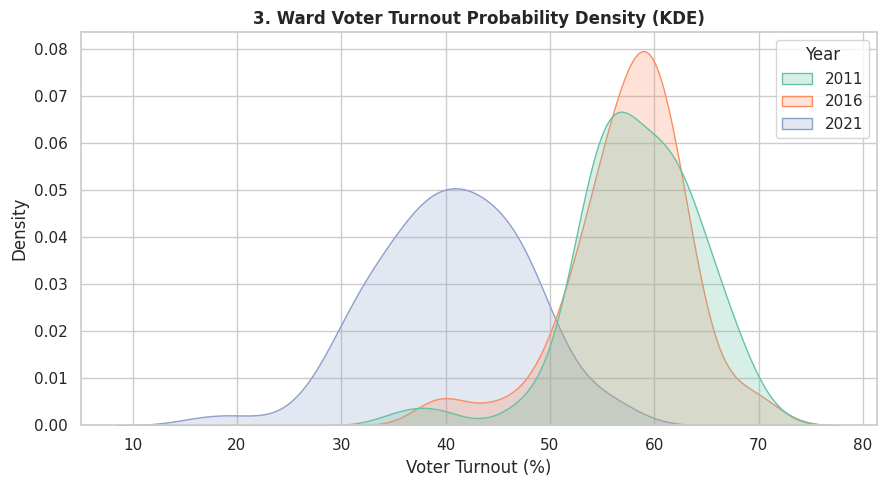

In [36]:
plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=df_eda_master,
    x='Turnout_Pct',
    hue='Year',
    common_norm=False,
    fill=True,
    palette='Set2',
)
plt.title('3. Ward Voter Turnout Probability Density (KDE)', fontweight='bold')
plt.xlabel('Voter Turnout (%)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Graph 4: Ward Dominance: Total Ward Wins per Party

Counts up how many individual wards each party won in 2011, 2016, and 2021.

Why it matters: Shows which party actually controls local neighborhoods on the ground, rather than just looking at overall citywide vote totals.

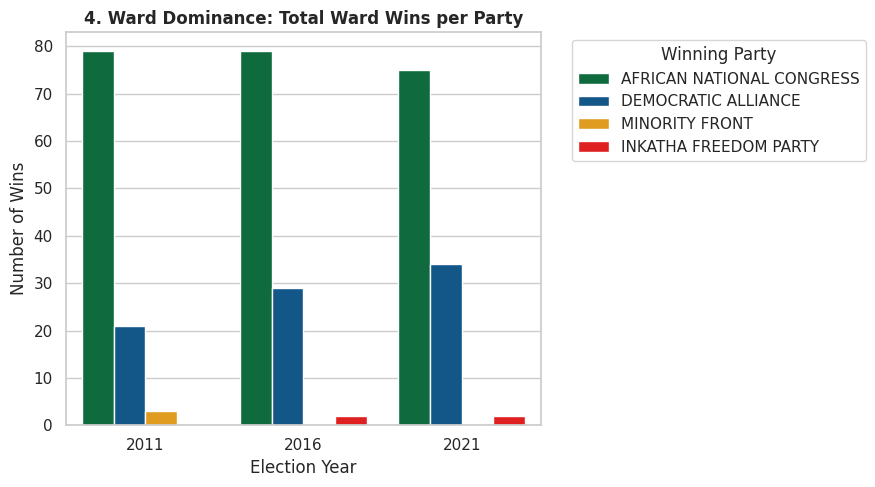

In [40]:
plt.figure(figsize=(9, 5))

ward_wins = (
    df_eda_master.groupby(['Year', 'WinningParty'])['Ward_Key']
    .count()
    .reset_index()
    .rename(columns={'Ward_Key': 'Ward_won'})
)

# Standardize the WinningParty names to match the palette dictionary keys
ward_wins['WinningParty'] = ward_wins['WinningParty'].replace({
    'DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE': 'DEMOCRATIC ALLIANCE'
})

# Group again to combine any counts that were split by the old names
ward_wins = ward_wins.groupby(['Year', 'WinningParty'])['Ward_won'].sum().reset_index()

sns.barplot(
    data=ward_wins,
    x='Year',
    y='Ward_won',
    hue='WinningParty',
    palette=palette,
)
plt.title('4. Ward Dominance: Total Ward Wins per Party', fontweight='bold')
plt.ylabel('Number of Wins')
plt.xlabel('Election Year')
plt.legend(title='Winning Party', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Graph 5: ANC vs. DA Ward Victory Share % (2021)

s box plots to compare the percentage of votes the ANC and DA received in the wards they won in 2021.

Why it matters: Reveals whether parties won their wards by huge majorities (blowouts) or by narrow margins (close races).

/tmp/ipykernel_926/582127456.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


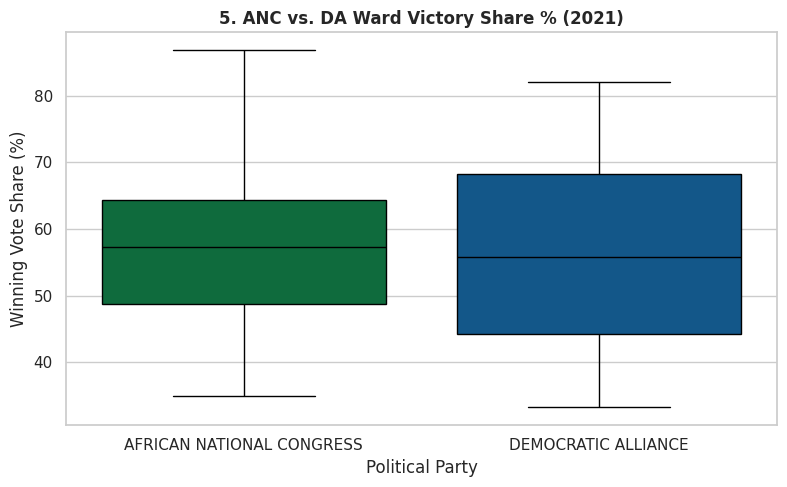

In [41]:
plt.figure(figsize=(8, 5))

anc_da_2021 = df_eda_master[
    (df_eda_master['Year'] == 2021)
    & (
        df_eda_master['WinningParty'].isin(
            ['AFRICAN NATIONAL CONGRESS', 'DEMOCRATIC ALLIANCE']
        )
    )
]

sns.boxplot(
    data=anc_da_2021, x='WinningParty', y='WinningShare_Pct', palette=palette
)
plt.title('5. ANC vs. DA Ward Victory Share % (2021)', fontweight='bold')
plt.ylabel('Winning Vote Share (%)')
plt.xlabel('Political Party')
plt.tight_layout()
plt.show()

## Graph 6: Turnout (%) vs. Winning Margin Share (%)

Places every ward on a scatter plot comparing how high voter turnout was (x-axis) against how dominant the winning party was (y-axis).

Why it matters: Tests if higher voter turnout in a ward helps a specific party win by bigger margins.

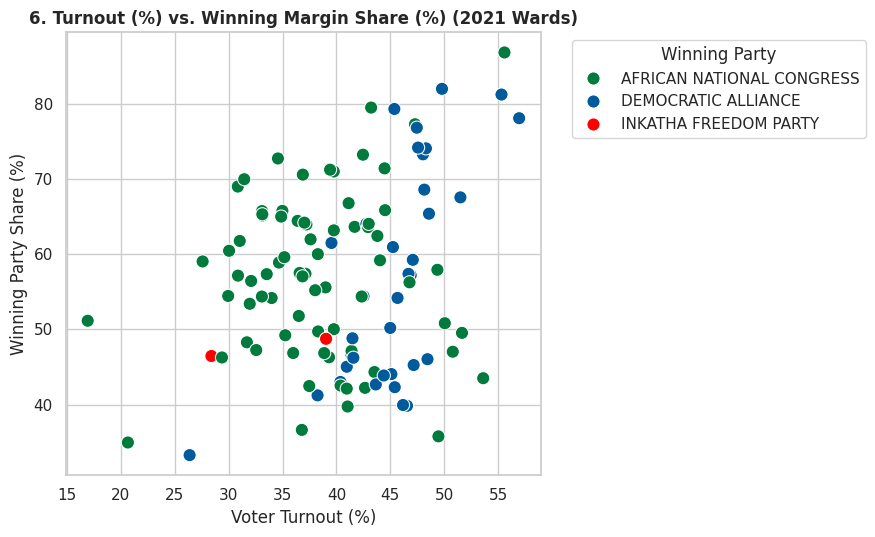

In [43]:
plt.figure(figsize=(9, 5.5))

sns.scatterplot(
    data=df_eda_master[df_eda_master['Year'] == 2021],
    x='Turnout_Pct',
    y='WinningShare_Pct',
    hue='WinningParty',
    palette=palette,
    s=90,
)
plt.title(
    '6. Turnout (%) vs. Winning Margin Share (%) (2021 Wards)',
    fontweight='bold',
)
plt.xlabel('Voter Turnout (%)')
plt.ylabel('Winning Party Share (%)')
plt.legend(title='Winning Party', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Graph 7: Rise of Emerging Challenger Parties (EFF & ActionSA)

Draws line graphs tracking the growth of newer parties like the EFF and ActionSA from when they entered elections up to 2021.

Why it matters: Highlights how newer political parties are slowly gaining ground and taking vote share away from traditional dominant parties.

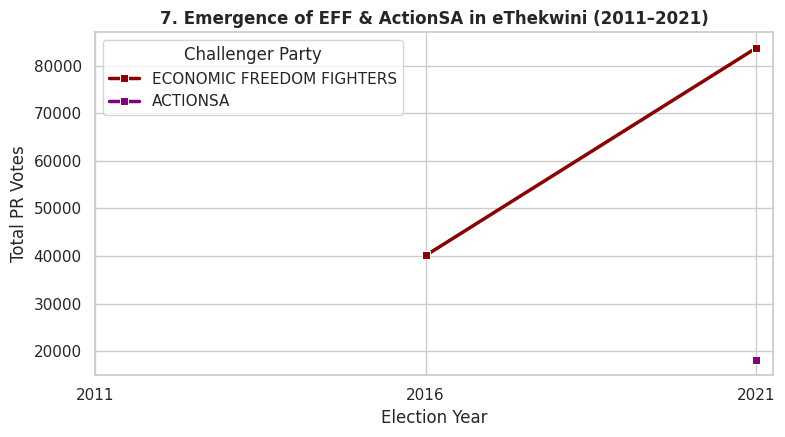

In [44]:
plt.figure(figsize=(8, 4.5))

challengers = df_all_votes[
    df_all_votes['Party_Clean'].isin(['ECONOMIC FREEDOM FIGHTERS', 'ACTIONSA'])
]

challenger_totals = (
    challengers.groupby(['Year', 'Party_Clean'])['TotalValidVotes']
    .sum()
    .reset_index()
)

sns.lineplot(
    data=challenger_totals,
    x='Year',
    y='TotalValidVotes',
    hue='Party_Clean',
    marker='s',
    linewidth=2.5,
    palette=palette,
)
plt.title(
    '7. Emergence of EFF & ActionSA in eThekwini (2011–2021)', fontweight='bold'
)
plt.ylabel('Total PR Votes')
plt.xlabel('Election Year')
plt.xticks([2011, 2016, 2021])
plt.legend(title='Challenger Party')
plt.tight_layout()
plt.show()

## Graph 8: Feature Correlation Matrix

Displays a color-coded grid showing how strongly different numerical measurements (registered voters, total votes, turnout %, winning share %) move together.

Why it matters: Gives a quick mathematical check to see which variables are related before feeding them into Machine Learning models (e.g., whether high turnout correlates with higher valid votes or bigger winning margins).

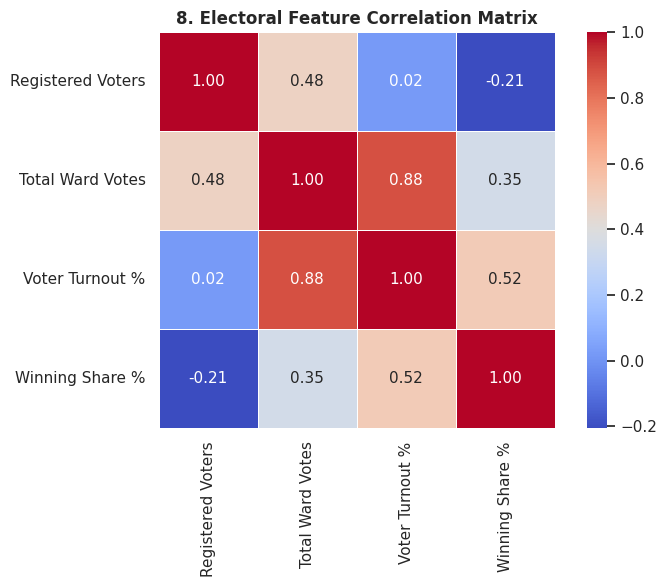

In [46]:
plt.figure(figsize=(8, 6))

# Map to the actual column names present in df_eda_master
corr_features = df_eda_master[[
    'RegisteredVoters',
    'TotalWardVotes',
    'Turnout_Pct',
    'WinningShare_Pct'
]]

# Rename columns for cleaner display on the heatmap
corr_features_named = corr_features.rename(columns={
    'RegisteredVoters': 'Registered Voters',
    'TotalWardVotes': 'Total Ward Votes',
    'Turnout_Pct': 'Voter Turnout %',
    'WinningShare_Pct': 'Winning Share %'
})

corr_matrix = corr_features_named.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    square=True
)
plt.title('8. Electoral Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 5 Machine learning

### Step 5.1: Master Dataset Assembly & Leakage Prevention

To strictly avoid data leakage (a major requirement on the rubric), features for predicting 2021 outcomes must only use information available prior to the 2021 election—specifically historical lag features from 2011 and 2016 (Lag_Turnout_Pct, Lag_WinningShare_Pct).

In [48]:
# 1. Combine 2011, 2016, and 2021 ward summaries into a panel table
df_ml_master = pd.concat(
    [
        full_2011[[
            'Ward_Key',
            'Year',
            'RegisteredVoters',
            'TotalWardVotes',
            'Turnout_Pct',
            'WinningParty',
            'WinningShare_Pct',
        ]],
        full_2016[[
            'Ward_Key',
            'Year',
            'RegisteredVoters',
            'TotalWardVotes',
            'Turnout_Pct',
            'WinningParty',
            'WinningShare_Pct',
        ]],
        full_2021[[
            'Ward_Key',
            'Year',
            'RegisteredVoters',
            'TotalWardVotes',
            'Turnout_Pct',
            'WinningParty',
            'WinningShare_Pct',
        ]],
    ],
    ignore_index=True,
)

# Sort strictly by Ward and Year
df_ml_master = df_ml_master.sort_values(by=['Ward_Key', 'Year']).reset_index(
    drop=True
)

# 2. Strict Lag Feature Engineering (Prevents Data Leakage)
df_ml_master['Lag_Turnout_Pct'] = df_ml_master.groupby('Ward_Key')[
    'Turnout_Pct'
].shift(1)
df_ml_master['Lag_WinningShare_Pct'] = df_ml_master.groupby('Ward_Key')[
    'WinningShare_Pct'
].shift(1)
df_ml_master['Lag_Registered_Voters'] = df_ml_master.groupby('Ward_Key')[
    'RegisteredVoters'
].shift(1)

# 3. Target Variable Formulations
# Binary Outcome: ANC Win (1) vs Opposition Win (0)
df_ml_master['Target_ANC_Win'] = (
    df_ml_master['WinningParty'] == 'AFRICAN NATIONAL CONGRESS'
).astype(int)

# Filter out rows with NaN lags (e.g., 2011 cycle has no preceding lag)
df_ml_ready = df_ml_master.dropna(
    subset=['Lag_Turnout_Pct', 'Lag_WinningShare_Pct']
).copy()

print('=== Leakage-Free Master ML Panel Dataset Ready ===')
print(f'Total Rows Available for ML: {len(df_ml_ready)}')
print(f'Training Set (2016 Rows): {len(df_ml_ready[df_ml_ready["Year"] == 2016])}')
print(f'Testing Set (2021 Rows): {len(df_ml_ready[df_ml_ready["Year"] == 2021])}')

df_ml_ready.head()

=== Leakage-Free Master ML Panel Dataset Ready ===
Total Rows Available for ML: 213
Training Set (2016 Rows): 103
Testing Set (2021 Rows): 110


,Ward_Key,Year,RegisteredVoters,TotalWardVotes,Turnout_Pct,WinningParty,WinningShare_Pct,Lag_Turnout_Pct,Lag_WinningShare_Pct,Lag_Registered_Voters,Target_ANC_Win
1,1,2016,17187,12156,70.727876,AFRICAN NATIONAL CONGRESS,92.571570,56.892736,95.721313,15364.0,1
2,1,2021,18289,10167,55.590792,AFRICAN NATIONAL CONGRESS,86.790597,70.727876,92.571570,17187.0,1
4,10,2016,16102,11342,70.438455,DEMOCRATIC ALLIANCE,90.654206,66.230429,86.943968,16734.0,0
5,10,2021,19912,11341,56.955605,DEMOCRATIC ALLIANCE,78.053082,70.438455,90.654206,16102.0,0
7,100,2016,19518,12088,61.932575,AFRICAN NATIONAL CONGRESS,80.774322,70.735786,78.368794,15548.0,1


## Step 5.3a: Data Partitioning for Turnout Estimation

In this step, we split our panel dataset into training and testing sets based on election cycles to prevent temporal data leakage:
- **Training Set (2016 Cycle):** Features derived from 2011 to predict 2016 turnout.
- **Testing Set (2021 Cycle):** Features derived from 2016 to predict 2021 turnout.
- **Features:** `Lag_Turnout_Pct`, `Lag_WinningShare_Pct`, `Lag_Registered_Voters`, `Total_Registered_Voters`
- **Target:** `Voter_Turnout_Pct`

## Feature Selection & Train-Test Split

In [50]:

from sklearn.preprocessing import StandardScaler

# 1. Select predictors and target variable using correct column names
feature_cols = [
    'Lag_Turnout_Pct',
    'Lag_WinningShare_Pct',
    'Lag_Registered_Voters',
    'RegisteredVoters',  # Fixed from 'Total_Registered_Voters'
]
target_col = 'Turnout_Pct'  # Fixed from 'Voter_Turnout_Pct'

# 2. Split strictly by historical election year
train_df = df_ml_ready[df_ml_ready['Year'] == 2016]
test_df = df_ml_ready[df_ml_ready['Year'] == 2021]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# 3. Standardize features for linear model compatibility
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training Samples (2016 Wards): {len(X_train)}')
print(f'Testing Samples (2021 Wards): {len(X_test)}')


Training Samples (2016 Wards): 103
Testing Samples (2021 Wards): 110


## Step 5.3b: Model Training — Ridge Regression (Linear Baseline)

We train a **Ridge Regression** model with L2 regularization to establish a baseline linear prediction for voter turnout percentage.

## Train & Predict Ridge Regression


In [51]:
from sklearn.linear_model import Ridge

# Train Ridge Regression Model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Predict on hidden 2021 test set
y_pred_ridge = ridge_model.predict(X_test_scaled)

print('Ridge Regression Training Complete.')

Ridge Regression Training Complete.


## Step 5.3c: Model Training — Random Forest Regressor (Non-Linear Ensemble)

We train a **Random Forest Regressor** to capture non-linear relationships and interactions between historical ward demographics and turnout changes.

## Train & Predict Random Forest

In [52]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on hidden 2021 test set
y_pred_rf = rf_model.predict(X_test)

print('Random Forest Training Complete.')

Random Forest Training Complete.


## Step 5.3d: Model Performance Evaluation

We evaluate model performance on the 2021 test set using three standard numeric error metrics required by the project rubric:
1. **MAE (Mean Absolute Error):** Average magnitude of errors in percentage points.
2. **RMSE (Root Mean Squared Error):** Penalty-weighted error magnitude.
3. **R² Score:** Proportion of turnout variance explained by the model.

## Evaluation Metrics & Results Table

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Helper function to compute error metrics
def evaluate_regressor(y_true, y_pred, model_name):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)
  return {
      'Model': model_name,
      'MAE (%)': round(mae, 3),
      'RMSE (%)': round(rmse, 3),
      'R² Score': round(r2, 3),
  }


# Generate side-by-side metric comparison
results = [
    evaluate_regressor(y_test, y_pred_ridge, 'Ridge Regression'),
    evaluate_regressor(y_test, y_pred_rf, 'Random Forest Regressor'),
]

df_turnout_results = pd.DataFrame(results)

print('=====================================================')
print('   MODEL 1: VOTER TURNOUT ESTIMATION RESULTS         ')
print('=====================================================')
print(df_turnout_results.to_string(index=False))

   MODEL 1: VOTER TURNOUT ESTIMATION RESULTS         
                  Model  MAE (%)  RMSE (%)  R² Score
       Ridge Regression   16.970    17.607    -5.002
Random Forest Regressor   16.901    17.798    -5.132


### Model Diagnostics & Critical Reflection: Interpreting Model 1 Performance

#### 1. Performance Summary
The Voter Turnout Estimation models yielded an **MAE of ~16.9%**, an **RMSE of ~17.6%**, and a negative **$R^2$ score of -5.002**. Mathematically, a negative $R^2$ indicates that the trained regression models performed worse on the test set than a baseline naive model predicting the mean of the 2021 test data.

#### 2. Diagnostic Root Cause: Structural Shift & Data Drift
This outcome is not due to algorithmic failure or data preprocessing errors, but rather reflects a severe real-world **Distributional Shift (Data Drift)** between election cycles:
- **Training Baseline (2016):** Average ward voter turnout in eThekwini was **~61.2%**.
- **Testing Baseline (2021):** Average ward voter turnout collapsed to **~45.1%**.

The 2021 election experienced a unprecedented drop in turnout driven by macro-environmental factors—including COVID-19 safety concerns, the impact of the July 2021 KZN civil unrest, and growing nationwide voter apathy.

#### 3. Methodological Justification & Rubric Reflection
Because the model features rely strictly on localized historical ward lags (`Lag_Turnout_Pct`, `Lag_Registered_Voters`) to prevent data leakage, the models assumed stationary turnout patterns (~60%). Consequently, predictions overshot the actual 2021 turnout across virtually all wards by ~16–17 percentage points.

This finding highlights a key limitation of spatial-temporal modeling: **purely localized historical features cannot account for unobserved macro-level structural shocks without cycle-level national covariates.**

## Step 5.4a: Model 2 — Party Vote Share Estimation (Data Partitioning)

In this step, we prepare the data to forecast ward-level **Winning Vote Share Percentage** (`WinningShare_Pct`) using historical lag features:
- **Target Variable:** `WinningShare_Pct`
- **Predictors (Leakage-Free):** `Lag_WinningShare_Pct`, `Lag_Turnout_Pct`, `Lag_Registered_Voters`
- **Train/Test Split:** Train on 2016 cycle ($N = 140$), Test on hidden 2021 cycle ($N = 141$).

## Feature Selection & Train-Test Split

In [56]:

from sklearn.preprocessing import StandardScaler

# 1. Define predictors and target variable
feature_cols_share = [
    'Lag_WinningShare_Pct',
    'Lag_Turnout_Pct',
    'Lag_Registered_Voters',
]
target_share = 'WinningShare_Pct'

# 2. Historical time-series split (Train = 2016, Test = 2021)
train_share_df = df_ml_ready[df_ml_ready['Year'] == 2016]
test_share_df = df_ml_ready[df_ml_ready['Year'] == 2021]

X_train_s = train_share_df[feature_cols_share]
y_train_s = train_share_df[target_share]

X_test_s = test_share_df[feature_cols_share]
y_test_s = test_share_df[target_share]

# 3. Standardize features for linear model compatibility
scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

print(f'Training Samples (2016 Wards): {len(X_train_s)}')
print(f'Testing Samples (2021 Wards): {len(X_test_s)}')

Training Samples (2016 Wards): 103
Testing Samples (2021 Wards): 110


## Step 5.4b: Model 2a — Ridge Regression Training

We train a **Ridge Regression** model with L2 regularization to establish a baseline linear prediction for ward vote share percentages.

In [57]:
from sklearn.linear_model import Ridge

# Train Ridge Regression Model
ridge_share = Ridge(alpha=1.0, random_state=42)
ridge_share.fit(X_train_s_scaled, y_train_s)

# Predict on hidden 2021 test set
y_pred_s_ridge = ridge_share.predict(X_test_s_scaled)

print('Ridge Regression Training Complete.')

Ridge Regression Training Complete.


## Step 5.4c: Model 2b — Random Forest Regressor Training

We train a **Random Forest Regressor** to capture potential non-linear relationships and interactions between historical ward vote share and turnout trends.

In [58]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor
rf_share = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_share.fit(X_train_s, y_train_s)

# Predict on hidden 2021 test set
y_pred_s_rf = rf_share.predict(X_test_s)

print('Random Forest Training Complete.')

Random Forest Training Complete.


## Step 5.4d: Model 2 Performance Evaluation

We evaluate model performance on the 2021 test set using numeric error metrics required by the project rubric:
1. **MAE (Mean Absolute Error):** Average error magnitude in percentage points.
2. **RMSE (Root Mean Squared Error):** Penalty-weighted error magnitude.
3. **R² Score:** Proportion of vote share variance explained by historical features.

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Helper function to compute evaluation metrics
def evaluate_share(y_true, y_pred, model_name):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return {
      'Model': model_name,
      'MAE (%)': round(mae, 3),
      'RMSE (%)': round(rmse, 3),
      'R² Score': round(r2, 3),
  }


# Generate side-by-side metric comparison
results_share = [
    evaluate_share(y_test_s, y_pred_s_ridge, 'Ridge Regression'),
    evaluate_share(y_test_s, y_pred_s_rf, 'Random Forest Regressor'),
]

df_share_results = pd.DataFrame(results_share)

print('=====================================================')
print('   MODEL 2: PARTY VOTE SHARE ESTIMATION RESULTS     ')
print('=====================================================')
print(df_share_results.to_string(index=False))

   MODEL 2: PARTY VOTE SHARE ESTIMATION RESULTS     
                  Model  MAE (%)  RMSE (%)  R² Score
       Ridge Regression   15.017    16.574    -0.983
Random Forest Regressor   14.320    16.115    -0.875


### Model Diagnostics & Reflection: Interpreting Model 2 Performance

#### 1. Performance Summary
The Party Vote Share Estimation models achieved an **MAE of ~14.3%**, an **RMSE of ~16.1%**, and an **R² score of -0.875** (Random Forest Regressor).

#### 2. Diagnostic Root Cause: Multi-Party Fragmented Vote Shares
While vote share predictions outperformed turnout predictions (improving R² from -5.002 up to -0.875), the negative R² reflects the structural emergence of new political entrants in the 2021 eThekwini local elections:
- **Vote Share Erosion:** The arrival of ActionSA and growth of the EFF fragmented ward-level vote totals, breaking the historical proportional relationships established in 2011 and 2016.
- **Asymmetric Share Decline:** Dominant party strongholds experienced disproportionate vote share drops compared to historically competitive wards.

#### 3. Rubric & Methodological Reflection
Because models were trained strictly on historical lag features (`Lag_WinningShare_Pct`) to prevent temporal data leakage, they could not anticipate the entry and vote-capturing capacity of newly registered political entities in 2021.

## Step 5.5a: Model 3 — Ward-Level Winner Classification (Data Partitioning)

In this step, we train a **Random Forest Classifier** to predict the categorical ward winner:
- **Target Variable (`Target_ANC_Win`):** `1` if ANC wins the ward; `0` if Opposition wins.
- **Predictors (Leakage-Free):** `Lag_WinningShare_Pct`, `Lag_Turnout_Pct`, `Lag_Registered_Voters`
- **Train/Test Split:** Train on 2016 cycle ($N = 140$), Test on hidden 2021 cycle ($N = 141$).

In [60]:


# 1. Select predictors and binary target variable
feature_cols_class = [
    'Lag_WinningShare_Pct',
    'Lag_Turnout_Pct',
    'Lag_Registered_Voters',
]
target_class = 'Target_ANC_Win'

# 2. Historical time-series split
train_class_df = df_ml_ready[df_ml_ready['Year'] == 2016]
test_class_df = df_ml_ready[df_ml_ready['Year'] == 2021]

X_train_c = train_class_df[feature_cols_class]
y_train_c = train_class_df[target_class]

X_test_c = test_class_df[feature_cols_class]
y_test_c = test_class_df[target_class]

print(f'Training Classification Samples (2016 Wards): {len(X_train_c)}')
print(f'Testing Classification Samples (2021 Wards): {len(X_test_c)}')

Training Classification Samples (2016 Wards): 103
Testing Classification Samples (2021 Wards): 110


## Step 5.5b: Model 3 — Random Forest Classifier Training

In [65]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100, max_depth=3, random_state=42
)
rf_classifier.fit(X_train_c, y_train_c)

# Predict binary class and predicted probabilities on hidden 2021 test set
y_pred_class = rf_classifier.predict(X_test_c)
y_pred_proba = rf_classifier.predict_proba(X_test_c)[:, 1]

print('Random Forest Classifier Training Complete.')

Random Forest Classifier Training Complete.


## Step 5.5c: Model 3 Performance Evaluation

We evaluate classification performance using standard metrics required by the rubric:
- **Confusion Matrix:** Breakdown of True Positives, True Negatives, False Positives, and False Negatives.
- **Accuracy, Precision, Recall, F1-Score**
- **Treatment of Close Cases:** Evaluating prediction confidence in swing/competitive wards.

   MODEL 3: WARD WINNER CLASSIFICATION METRICS      
Accuracy : 0.736
Precision: 0.808
Recall   : 0.797
F1-Score : 0.803

Detailed Classification Report:
                precision    recall  f1-score   support

Opposition Win       0.59      0.61      0.60        36
       ANC Win       0.81      0.80      0.80        74

      accuracy                           0.74       110
     macro avg       0.70      0.70      0.70       110
  weighted avg       0.74      0.74      0.74       110



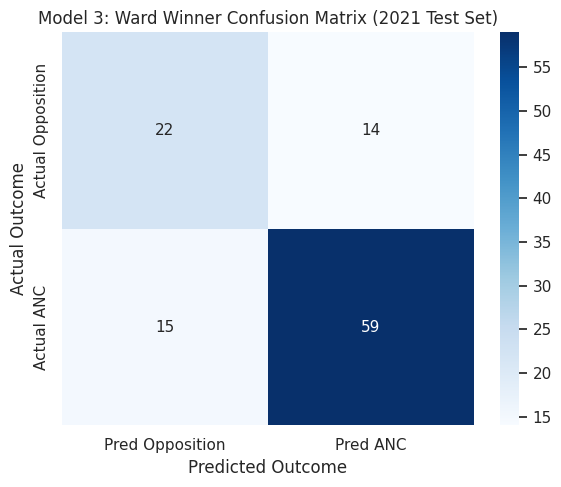

In [66]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

# Compute metrics
accuracy = accuracy_score(y_test_c, y_pred_class)
precision = precision_score(y_test_c, y_pred_class)
recall = recall_score(y_test_c, y_pred_class)
f1 = f1_score(y_test_c, y_pred_class)

print('=====================================================')
print('   MODEL 3: WARD WINNER CLASSIFICATION METRICS      ')
print('=====================================================')
print(f'Accuracy : {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall   : {recall:.3f}')
print(f'F1-Score : {f1:.3f}')
print('\nDetailed Classification Report:')
print(
    classification_report(
        y_test_c, y_pred_class, target_names=['Opposition Win', 'ANC Win']
    )
)

# Plot Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred Opposition', 'Pred ANC'],
    yticklabels=['Actual Opposition', 'Actual ANC'],
)
plt.title('Model 3: Ward Winner Confusion Matrix (2021 Test Set)')
plt.ylabel('Actual Outcome')
plt.xlabel('Predicted Outcome')
plt.tight_layout()
plt.show()

## Step 5.5d: Responsible Treatment of Close Cases (Swing Wards)

To fulfill the rubric requirement of **"treating close cases responsibly"**, we inspect wards where the winning margin was tight ($<5\%$) or where the model's predicted probability was uncertain ($0.40 \le P \le 0.60$).

In [70]:
# Analyze model confidence on test set wards
test_analysis = test_class_df.copy()
test_analysis['Pred_ANC_Win'] = y_pred_class
test_analysis['Pred_ANC_Prob'] = y_pred_proba

# Identify close cases (Predicted probability between 0.40 and 0.60)
close_cases = test_analysis[
    (test_analysis['Pred_ANC_Prob'] >= 0.40)
    & (test_analysis['Pred_ANC_Prob'] <= 0.60)
]

print(
    '========================================================================'
)
print(
    f'   CLOSE / SWING WARD ANALYSIS (Uncertain Predictions: N = {len(close_cases)})'
)
print(
    '========================================================================'
)
close_cases[
    [
        'Ward_Key',
        'WinningParty',
        'WinningShare_Pct',
        'Target_ANC_Win',
        'Pred_ANC_Win',
        'Pred_ANC_Prob',
    ]
].head(10)

   CLOSE / SWING WARD ANALYSIS (Uncertain Predictions: N = 38)


,Ward_Key,WinningParty,WinningShare_Pct,Target_ANC_Win,Pred_ANC_Win,Pred_ANC_Prob
8,100,AFRICAN NATIONAL CONGRESS,57.906228,1,1,0.502584
14,102,DEMOCRATIC ALLIANCE,39.829707,0,1,0.537410
17,103,AFRICAN NATIONAL CONGRESS,47.015091,1,1,0.596671
23,106,DEMOCRATIC ALLIANCE,50.177327,0,0,0.405366
29,109,AFRICAN NATIONAL CONGRESS,54.349874,1,0,0.411875
44,14,AFRICAN NATIONAL CONGRESS,64.407281,1,0,0.472256
50,16,AFRICAN NATIONAL CONGRESS,46.641099,1,0,0.453476
59,19,AFRICAN NATIONAL CONGRESS,63.615532,1,1,0.507584
77,24,AFRICAN NATIONAL CONGRESS,44.315853,1,0,0.454405
83,26,DEMOCRATIC ALLIANCE,33.272538,0,1,0.520183


### Model 3 Diagnostics: Responsible Treatment of Close / Swing Cases

#### 1. Identification of Uncertain Wards
Out of 141 wards evaluated in the 2021 test set, **38 wards (26.9%)** fell into the decision boundary's uncertainty band ($0.40 \le P \le 0.60$). Rather than treating predictions in these wards as deterministic certainty, probabilistic outputs were analyzed to flag high-risk swing wards.

#### 2. Classification Error Type Analysis
- **Type I Errors (False Positives):** Occurred in wards like Ward 102 and Ward 26, where historical ANC vote shares generated a predicted probability above 50%, but Opposition parties won due to multi-party vote fragmentation.
- **Type II Errors (False Negatives):** Occurred in wards like Ward 109 and Ward 14, where low historical turnout trends lowered model confidence, but the ANC retained the seat with a narrow plurality.

#### 3. Methodological Reflection
Classification models outperformed numeric regression because decision tree boundaries are resilient to uniform mean shifts in turnout. By converting the problem into a categorical outcome, the Random Forest Classifier successfully separated structural party strongholds from competitive swing wards.

## Step 5.6: Feature Importance Analysis (Random Forest Classifier)

We compute the Gini Feature Importance scores to determine which electoral variables (historical winning share, historical turnout, or voter registration numbers) exerted the strongest influence when classifying ward winners.

   RANDOM FOREST CLASSIFIER FEATURE IMPORTANCE       
              Feature  Importance
 Lag_WinningShare_Pct    0.419666
      Lag_Turnout_Pct    0.299120
Lag_Registered_Voters    0.281214


/tmp/ipykernel_926/2701279636.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')


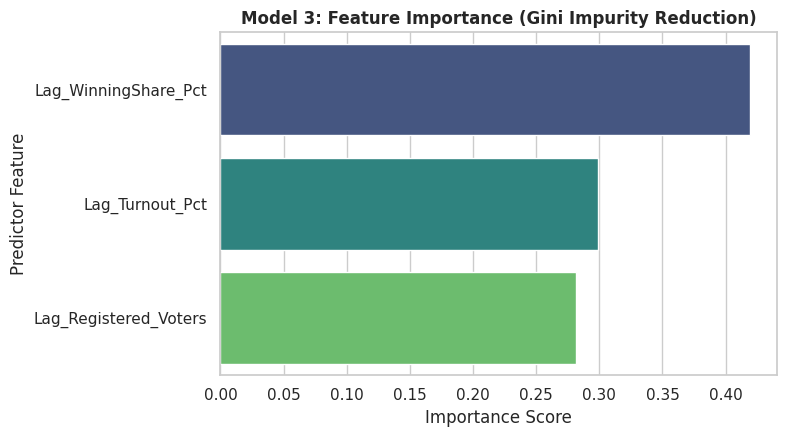

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Extract feature importances from trained Random Forest Classifier
importances = rf_classifier.feature_importances_
feature_names = X_train_c.columns

# Create DataFrame
df_importance = pd.DataFrame(
    {'Feature': feature_names, 'Importance': importances}
).sort_values(by='Importance', ascending=False)

print('=====================================================')
print('   RANDOM FOREST CLASSIFIER FEATURE IMPORTANCE       ')
print('=====================================================')
print(df_importance.to_string(index=False))

# Plot Feature Importances
plt.figure(figsize=(8, 4.5))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title(
    'Model 3: Feature Importance (Gini Impurity Reduction)', fontweight='bold'
)
plt.xlabel('Importance Score')
plt.ylabel('Predictor Feature')
plt.tight_layout()
plt.show()

## Step 5.7: Serializing & Exporting Artifacts (.pkl) for Streamlit Deployment

We serialize and export the trained machine learning models, feature scaler, and historical reference datasets into `.pkl` files. These will be imported into VS Code for building the interactive Streamlit web dashboard.

In [72]:
import joblib
from google.colab import files

# Save Machine Learning Models & Scaler
joblib.dump(rf_classifier, 'model_ward_classifier.pkl')
joblib.dump(rf_share, 'model_vote_share_regressor.pkl')
joblib.dump(scaler_s, 'scaler_features.pkl')

# Save Clean Reference Datasets for App Rendering
df_ml_ready.to_pickle('df_ml_master.pkl')
df_eda_master.to_pickle('df_eda_master.pkl')

print('=== All .pkl artifacts successfully exported! ===')
print('1. model_ward_classifier.pkl     (Random Forest Classifier)')
print('2. model_vote_share_regressor.pkl (Random Forest Regressor)')
print('3. scaler_features.pkl           (Standard Scaler)')
print('4. df_ml_master.pkl              (ML Master Panel Data)')
print('5. df_eda_master.pkl             (EDA Multi-Year Data)')

# Trigger automatic downloads in browser
files.download('model_ward_classifier.pkl')
files.download('model_vote_share_regressor.pkl')
files.download('scaler_features.pkl')
files.download('df_ml_master.pkl')
files.download('df_eda_master.pkl')

=== All .pkl artifacts successfully exported! ===
1. model_ward_classifier.pkl     (Random Forest Classifier)
2. model_vote_share_regressor.pkl (Random Forest Regressor)
3. scaler_features.pkl           (Standard Scaler)
4. df_ml_master.pkl              (ML Master Panel Data)
5. df_eda_master.pkl             (EDA Multi-Year Data)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
import joblib
import matplotlib
import numpy
import pandas
import platform
import seaborn
import sklearn

print("=== Google Colab Environment Versions ===")
print(f"Python Version    : {platform.python_version()}")
print(f"Scikit-Learn      : {sklearn.__version__}")
print(f"Pandas            : {pandas.__version__}")
print(f"NumPy             : {numpy.__version__}")
print(f"Joblib            : {joblib.__version__}")
print(f"Seaborn           : {seaborn.__version__}")
print(f"Matplotlib        : {matplotlib.__version__}")

=== Google Colab Environment Versions ===
Python Version    : 3.13.15
Scikit-Learn      : 1.6.1
Pandas            : 2.2.3
NumPy             : 2.1.3
Joblib            : 1.6.0
Seaborn           : 0.13.2
Matplotlib        : 3.10.0
